In [1]:
!pip uninstall -y transformers -q

!pip install transformers==4.46.3 datasets accelerate sentencepiece evaluate rouge_score sacrebleu -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 85.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import random
import numpy as np
import pandas as pd
import torch
import transformers

from datasets import Dataset
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)

In [3]:
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

Transformers: 4.46.3
PyTorch: 2.11.0+cu128
CUDA: True


In [4]:
dataset_path = "/content/drive/MyDrive/combined_cleaned.json"

with open(dataset_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Total Records:", len(data))

Total Records: 21004


In [5]:
df = pd.DataFrame(data)

df.head()

,instruction,input,output
0,Rewrite the given university examination quest...,Source Bloom: Remember | Target Bloom: Underst...,Explain why mixed qualitative and quantitative...
1,Rewrite the given university examination quest...,Source Bloom: Remember | Target Bloom: Apply |...,Demonstrate how mixed qualitative and quantita...
2,Rewrite the given university examination quest...,Source Bloom: Remember | Target Bloom: Analyze...,Analyze the advantages of using mixed qualitat...
3,Rewrite the given university examination quest...,Source Bloom: Remember | Target Bloom: Evaluat...,Assess the suitability of mixed qualitative an...
4,Rewrite the given university examination quest...,Source Bloom: Remember | Target Bloom: Create ...,Develop a mixed methods research framework for...


In [6]:
print("="*60)

print("DATASET STATISTICS")

print("="*60)

print("Total Records:", len(df))

print("Unique Instructions:", df["instruction"].nunique())

print()

print(df.columns)

DATASET STATISTICS
Total Records: 21004
Unique Instructions: 1

Index(['instruction', 'input', 'output'], dtype='object')


In [7]:
train_df, val_df = train_test_split(
    df,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

print("Training Samples :", len(train_df))
print("Validation Samples:", len(val_df))

Training Samples : 18903
Validation Samples: 2101


In [8]:
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 18903
})
Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 2101
})


In [9]:
MODEL_NAME = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

model.cuda()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [10]:
print(type(model))
print(model.device)

<class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
cuda:0


In [11]:
def preprocess_function(examples):

    inputs = [
        inst + "\n\n" + inp
        for inst, inp in zip(
            examples["instruction"],
            examples["input"]
        )
    ]

    model_inputs = tokenizer(
        inputs,
        max_length=256,
        truncation=True,
        padding=False
    )

    labels = tokenizer(
        text_target=examples["output"],
        max_length=128,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [12]:
train_tokenized = train_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=train_dataset.column_names
)

val_tokenized = val_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=val_dataset.column_names
)

Map:   0%|          | 0/18903 [00:00<?, ? examples/s]

Map:   0%|          | 0/2101 [00:00<?, ? examples/s]

In [13]:
print(train_tokenized)
print(val_tokenized)

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 18903
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2101
})


In [14]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

In [15]:
batch = data_collator([train_tokenized[0]])

batch = {
    k: v.to(model.device)
    for k, v in batch.items()
}

print(model(**batch).loss)

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


tensor(3.6216, device='cuda:0', grad_fn=<NllLossBackward0>)


In [16]:
print(len(train_tokenized))
print(len(val_tokenized))

18903
2101


In [17]:
training_args = Seq2SeqTrainingArguments(

    output_dir="/content/drive/MyDrive/flan_t5_model",

    num_train_epochs=5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=5e-5,
    weight_decay=0.01,

    evaluation_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    logging_strategy="epoch",

    predict_with_generate=True,

    fp16=False,

    save_total_limit=2,

    report_to="none"
)

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [18]:
print(training_args)

Seq2SeqTrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH

In [19]:
trainer = Seq2SeqTrainer(

    model=model,

    args=training_args,

    train_dataset=train_tokenized,

    eval_dataset=val_tokenized,

    tokenizer=tokenizer,

    data_collator=data_collator,
)

/tmp/ipykernel_1463/1739488127.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [20]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,2.470700,2.037732
2,2.071700,1.899131
3,1.918000,1.831723
4,1.827900,1.798716
5,1.779700,1.788145


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


TrainOutput(global_step=11815, training_loss=2.0135948410389335, metrics={'train_runtime': 4984.3914, 'train_samples_per_second': 18.962, 'train_steps_per_second': 2.37, 'total_flos': 1.3340607242646528e+16, 'train_loss': 2.0135948410389335, 'epoch': 5.0})

In [21]:
trainer.save_model("/content/drive/MyDrive/flan_t5_model")

tokenizer.save_pretrained("/content/drive/MyDrive/flan_t5_model")

('/content/drive/MyDrive/flan_t5_model/tokenizer_config.json',
 '/content/drive/MyDrive/flan_t5_model/special_tokens_map.json',
 '/content/drive/MyDrive/flan_t5_model/spiece.model',
 '/content/drive/MyDrive/flan_t5_model/added_tokens.json',
 '/content/drive/MyDrive/flan_t5_model/tokenizer.json')

In [22]:
import os

print(os.listdir("/content/drive/MyDrive/flan_t5_model"))

['checkpoint-9452', 'checkpoint-11815', 'config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'spiece.model', 'tokenizer.json', 'training_args.bin']


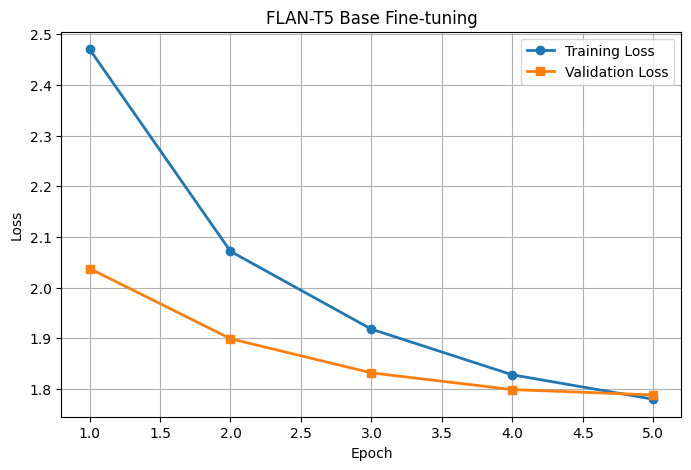

In [23]:
import matplotlib.pyplot as plt

history = trainer.state.log_history

train_loss = []
eval_loss = []
epochs = []

for log in history:

    if "loss" in log:
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        epochs.append(log["epoch"])

plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss, marker="o", linewidth=2, label="Training Loss")
plt.plot(epochs, eval_loss, marker="s", linewidth=2, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FLAN-T5 Base Fine-tuning")

plt.grid(True)

plt.legend()

plt.show()

In [24]:
plt.savefig("/content/drive/MyDrive/flan_t5_model/loss_curve.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [25]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_path="/content/drive/MyDrive/flan_t5_model"

tokenizer=AutoTokenizer.from_pretrained(model_path)

model=AutoModelForSeq2SeqLM.from_pretrained(model_path)

model.cuda()

model.eval()

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [26]:
instruction = "Rewrite the given university examination question from the source Bloom's Taxonomy level to the target Bloom's Taxonomy level while preserving the original concept, topic, and academic meaning. Return only the rewritten question."

input_text = """Source Bloom: Remember | Target Bloom: Analyze | Domain: Operating Systems | Topic: Deadlock | Question: Define deadlock."""

prompt = instruction + "\n\n" + input_text

inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=64,
    num_beams=4,
    early_stopping=True
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Differentiate deadlock from recursion in an operating system.


In [28]:
test_questions = [

{
"instruction":"Rewrite the given university examination question from the source Bloom's Taxonomy level to the target Bloom's Taxonomy level while preserving the original concept, topic, and academic meaning. Return only the rewritten question.",

"input":"Source Bloom: Remember | Target Bloom: Create | Domain: DBMS | Topic: Normalization | Question: Define normalization."
},

{
"instruction":"Rewrite the given university examination question from the source Bloom's Taxonomy level to the target Bloom's Taxonomy level while preserving the original concept, topic, and academic meaning. Return only the rewritten question.",

"input":"Source Bloom: Apply | Target Bloom: Evaluate | Domain: Computer Networks | Topic: Routing | Question: Apply Dijkstra's algorithm to determine the shortest path."
}

]
for sample in test_questions:

    prompt = sample["instruction"] + "\n\n" + sample["input"]

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=64,
        num_beams=4
    )

    print("="*80)
    print(sample["input"])
    print()
    print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Source Bloom: Remember | Target Bloom: Create | Domain: DBMS | Topic: Normalization | Question: Define normalization.

Develop a normalization strategy for a DBMS database.
Source Bloom: Apply | Target Bloom: Evaluate | Domain: Computer Networks | Topic: Routing | Question: Apply Dijkstra's algorithm to determine the shortest path.

Evaluate the effectiveness of Dijkstra's algorithm for shortest path estimation.


In [29]:
predictions = []
references = []

for sample in val_df.head(100).to_dict("records"):

    prompt = sample["instruction"] + "\n\n" + sample["input"]

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=64,
        num_beams=4,
        early_stopping=True
    )

    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)

    predictions.append(prediction)
    references.append(sample["output"])

print("Completed:", len(predictions))

Completed: 100


In [30]:
for i in range(10):

    print("="*100)

    print("INPUT")
    print(val_df.iloc[i]["input"])

    print()

    print("EXPECTED")
    print(references[i])

    print()

    print("PREDICTED")
    print(predictions[i])

    print()

INPUT
Source Bloom: Evaluate | Target Bloom: Remember | Domain: Computer Architecture and Embedded Systems | Topic: Peripheral Communication | Question: Compare SPI communication and I2C communication for embedded-device synchronization.

EXPECTED
Identify the communication protocols used in microprocessor interfacing.

PREDICTED
Recognize the protocol responsible for synchronization in embedded systems.

INPUT
Source Bloom: Understand | Target Bloom: Evaluate | Domain: Operating Systems | Topic: UNIX File System | Question: Explain the different file types in UNIX.

EXPECTED
Recommend the most suitable UNIX file type for the given storage requirement and justify your choice.

PREDICTED
Evaluate the suitability of different file types for storing UNIX files.

INPUT
Source Bloom: Understand | Target Bloom: Remember | Domain: Cyber Security | Topic: Authentication | Question: Describe Ticket and Ticket Granting Tickets in Kerberos.

EXPECTED
State the purpose of a Ticket in the Kerberos 

In [31]:
import evaluate

rouge = evaluate.load("rouge")

results = rouge.compute(
    predictions=predictions,
    references=references
)

print(results)

{'rouge1': np.float64(0.4098538628373428), 'rouge2': np.float64(0.23042587573273798), 'rougeL': np.float64(0.3929981772785008), 'rougeLsum': np.float64(0.393446932994157)}


In [32]:
bleu = evaluate.load("bleu")

bleu_score = bleu.compute(
    predictions=predictions,
    references=[[r] for r in references]
)

print(bleu_score)

{'bleu': 0.17541098368689945, 'precisions': [0.4556354916067146, 0.21980886185925283, 0.1455756422454805, 0.10830704521556257], 'brevity_penalty': 0.8799434087164463, 'length_ratio': 0.8866052445074415, 'translation_length': 1251, 'reference_length': 1411}


In [33]:
import pandas as pd

results_df = pd.DataFrame({
    "Input": val_df.head(100)["input"].tolist(),
    "Expected": references,
    "Predicted": predictions
})

results_df.to_csv(
    "/content/drive/MyDrive/flan_t5_model/model_predictions.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [34]:
import shutil

shutil.make_archive(
    "/content/drive/MyDrive/flan_t5_model",
    "zip",
    "/content/drive/MyDrive/flan_t5_model"
)

print("Model zipped successfully.")

Model zipped successfully.


In [38]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

old_model_path = "/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9"

old_tokenizer = AutoTokenizer.from_pretrained(old_model_path)

old_model = AutoModelForSeq2SeqLM.from_pretrained(old_model_path)

old_model.cuda()

old_model.eval()

print("Old model loaded successfully.")

Old model loaded successfully.


In [39]:
new_model_path = "/content/drive/MyDrive/flan_t5_model"

new_tokenizer = AutoTokenizer.from_pretrained(new_model_path)

new_model = AutoModelForSeq2SeqLM.from_pretrained(new_model_path)

new_model.cuda()

new_model.eval()

print("New model loaded successfully.")

New model loaded successfully.


In [40]:
test_samples = val_df.head(100).to_dict("records")

print("Total Test Samples:", len(test_samples))

Total Test Samples: 100


In [41]:
results = []

for sample in test_samples:

    prompt = sample["instruction"] + "\n\n" + sample["input"]

    # OLD MODEL

    inputs_old = old_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True
    ).to(old_model.device)

    outputs_old = old_model.generate(
        **inputs_old,
        max_new_tokens=64,
        num_beams=4
    )

    prediction_old = old_tokenizer.decode(
        outputs_old[0],
        skip_special_tokens=True
    )

    # NEW MODEL

    inputs_new = new_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True
    ).to(new_model.device)

    outputs_new = new_model.generate(
        **inputs_new,
        max_new_tokens=64,
        num_beams=4
    )

    prediction_new = new_tokenizer.decode(
        outputs_new[0],
        skip_special_tokens=True
    )

    results.append({

        "Input": sample["input"],

        "Expected": sample["output"],

        "Old Model": prediction_old,

        "New Model": prediction_new

    })

print("Comparison completed.")

Comparison completed.


In [42]:
import pandas as pd

comparison_df = pd.DataFrame(results)

comparison_df.to_csv(
    "/content/drive/MyDrive/flan_model_comparison.csv",
    index=False
)

comparison_df.head(20)

,Input,Expected,Old Model,New Model
0,Source Bloom: Evaluate | Target Bloom: Remembe...,Identify the communication protocols used in m...,meister impun impun impun impun impun impun im...,Recognize the protocol responsible for synchro...
1,Source Bloom: Understand | Target Bloom: Evalu...,Recommend the most suitable UNIX file type for...,schluss wieder wieder wieder impun impun impun...,Evaluate the suitability of different file typ...
2,Source Bloom: Understand | Target Bloom: Remem...,State the purpose of a Ticket in the Kerberos ...,meisteropéraopéra impun impun impun impun impu...,Define a Ticket Granting Ticket in Kerberos.
3,Source Bloom: Create | Target Bloom: Analyze |...,Classify network applications according to the...,schluss wieder wieder wieder Gö Gö Gö Gö Gö Gö...,Analyze the factors affecting the selection of...
4,Source Bloom: Understand | Target Bloom: Evalu...,Evaluate the suitability of FTP for transferri...,fühlt fühlt fühlt weil weil weil weil weil wei...,Evaluate the effectiveness of File Transfer Pr...
5,Source Bloom: Remember | Target Bloom: Create ...,Develop a comprehensive integration test sched...,meistermeisteruploadsuploadsuploadsuploadsuplo...,Design an integration testing strategy that in...
6,Source Bloom: Evaluate | Target Bloom: Underst...,Interpret how morphemes influence word formati...,schluss wieder wieder wieder wieder Gö Gö Gö G...,Summarize how morphology influences lexical in...
7,Source Bloom: Create | Target Bloom: Remember ...,Recognize the networking design that enables c...,meister impun impun impun impun impun impun im...,Define the SDN protocol responsible for forwar...
8,Source Bloom: Create | Target Bloom: Evaluate ...,Justify why your heuristic search solution out...,fühlt fühlt fühlt Cluj Cluj Cluj Cluj baie bai...,Assess the proposed heuristic search solution ...
9,Source Bloom: Evaluate | Target Bloom: Apply |...,Use register assignment for the given assembly...,baie baie baie baie baie baie baie Gö Gö Gö Gö...,Apply spill minimization for the supplied regi...


In [43]:
results = []

for sample in test_samples:

    prompt = sample["instruction"] + "\n\n" + sample["input"]

    # ==========================
    # OLD MODEL (v9)
    # ==========================

    inputs_old = old_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True
    ).to(old_model.device)

    outputs_old = old_model.generate(
        **inputs_old,
        max_new_tokens=80,
        num_beams=4,
        repetition_penalty=1.3,
        no_repeat_ngram_size=3,
        length_penalty=1.0,
        early_stopping=True
    )

    prediction_old = old_tokenizer.decode(
        outputs_old[0],
        skip_special_tokens=True
    )

    # ==========================
    # NEW MODEL
    # ==========================

    inputs_new = new_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True
    ).to(new_model.device)

    outputs_new = new_model.generate(
        **inputs_new,
        max_new_tokens=80,
        num_beams=4,
        repetition_penalty=1.3,
        no_repeat_ngram_size=3,
        length_penalty=1.0,
        early_stopping=True
    )

    prediction_new = new_tokenizer.decode(
        outputs_new[0],
        skip_special_tokens=True
    )

    results.append({

        "Input": sample["input"],
        "Expected": sample["output"],
        "Old Model": prediction_old,
        "New Model": prediction_new

    })

print("Comparison completed successfully.")

Comparison completed successfully.


In [44]:
import pandas as pd

comparison_df = pd.DataFrame(results)

comparison_df.to_csv(
    "/content/drive/MyDrive/flan_model_comparison1.csv",
    index=False
)

comparison_df.head(100)

,Input,Expected,Old Model,New Model
0,Source Bloom: Evaluate | Target Bloom: Remembe...,Identify the communication protocols used in m...,schluss wieder wieder wieder impun impun impun...,Recognize the protocol responsible for synchro...
1,Source Bloom: Understand | Target Bloom: Evalu...,Recommend the most suitable UNIX file type for...,schluss wieder wieder wieder impun impun impun...,Evaluate the suitability of different file typ...
2,Source Bloom: Understand | Target Bloom: Remem...,State the purpose of a Ticket in the Kerberos ...,meisteropéraopéra impun impun impun dés dés dé...,Define a ticket in Kerberos.
3,Source Bloom: Create | Target Bloom: Analyze |...,Classify network applications according to the...,schluss wieder wieder wieder Gö Gö Gö weil wei...,Analyze the factors affecting the selection of...
4,Source Bloom: Understand | Target Bloom: Evalu...,Evaluate the suitability of FTP for transferri...,schluss wieder wieder wiederdeshalbByronByron ...,Evaluate the effectiveness of File Transfer Pr...
...,...,...,...,...
95,Source Bloom: Understand | Target Bloom: Evalu...,Judge the impact of the Cultural Environment o...,schluss wieder wieder wiederlbstverständlichsc...,Evaluate the importance of the Cultural Enviro...
96,Source Bloom: Remember | Target Bloom: Analyze...,Analyze how the characteristics of Distributio...,schluss wieder wieder wieder impun impun impun...,Analyze how the characteristics of Distributio...
97,Source Bloom: Understand | Target Bloom: Evalu...,Evaluate the contribution of Training and Deve...,schluss wieder wieder wieder impun impun impun...,Evaluate the effectiveness of Training and Dev...
98,Source Bloom: Apply | Target Bloom: Analyze | ...,Examine the cost of moving memory blocks durin...,schluss wieder wieder wieder impun impun impun...,Examine the performance trade-offs of compacti...


In [46]:
import os

model_path = "/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9"

for file in sorted(os.listdir(model_path)):
    print(file)

config.json
generation_config.json
model.safetensors
tokenizer.json
tokenizer_config.json
training_args.bin


In [47]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9"):
    if "config.json" in files:
        print(root)

/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9


In [48]:
print(old_tokenizer.name_or_path)

/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9


In [49]:
print(old_model.config._name_or_path)
print(old_model.config.vocab_size)
print(old_model.config.model_type)

/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9
32128
t5


In [50]:
prompt = """Rewrite the given university examination question from the source Bloom's Taxonomy level to the target Bloom's Taxonomy level while preserving the original concept, topic, and academic meaning. Return only the rewritten question.

Source Bloom: Remember | Target Bloom: Analyze | Domain: DBMS | Topic: Normalization | Question: Define normalization."""

inputs = old_tokenizer(prompt, return_tensors="pt").to(old_model.device)

output = old_model.generate(
    **inputs,
    max_new_tokens=80,
    num_beams=4,
    repetition_penalty=1.3,
    no_repeat_ngram_size=3,
    length_penalty=1.0,
    early_stopping=True
)

print(old_tokenizer.decode(output[0], skip_special_tokens=True))

schluss wieder wieder wieder impun impun impun dés dés dés impun impun universitaire universitaire baie baie baie Gö Gö Gö Bhutan Bhutan Bhutan baie baieschuheschuhemöbelmöbelmöbelopéraopéraopéra fühlt weil weil weilScienceScience Wissenschaft Sprech Sprech Sprech Liege Liege LiegeUniversitéUniversitéUniversité Jamaica JamaicaEmmanuelEmmanuelEmmanuel universitaire universitaire Universität Universität Universitäthilfehilfehilfeschuheschuheschuhe Berufs Berufs Nieder Nieder Niedermeister weil weilByronByron Weiß Weiß Weiß weil weil


In [51]:
print(old_model.config)

T5Config {
  "_attn_implementation_autoset": true,
  "_name_or_path": "/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9",
  "architectures": [
    "T5ForConditionalGeneration"
  ],
  "classifier_dropout": 0.0,
  "d_ff": 2048,
  "d_kv": 64,
  "d_model": 768,
  "decoder_start_token_id": 0,
  "dense_act_fn": "gelu_new",
  "dropout_rate": 0.1,
  "dtype": "float32",
  "eos_token_id": 1,
  "feed_forward_proj": "gated-gelu",
  "initializer_factor": 1.0,
  "is_encoder_decoder": true,
  "is_gated_act": true,
  "layer_norm_epsilon": 1e-06,
  "model_type": "t5",
  "n_positions": 512,
  "num_decoder_layers": 12,
  "num_heads": 12,
  "num_layers": 12,
  "output_past": true,
  "pad_token_id": 0,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "scale_decoder_outputs": false,
  "task_specific_params": {
    "summarization": {
      "early_stopping": true,
      "length_penalty": 2.0,
      "max_length": 200,
      "min_length": 30,
      "no_repeat_ngram_size

In [52]:
print(old_model.config.vocab_size)

print(old_tokenizer.vocab_size)

32128
32100


In [53]:
print(old_model.config._name_or_path)

print(old_tokenizer.name_or_path)

/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9
/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9


In [54]:
prompt = """Rewrite the given university examination question from the source Bloom's Taxonomy level to the target Bloom's Taxonomy level while preserving the original concept, topic, and academic meaning. Return only the rewritten question.

Source Bloom: Remember | Target Bloom: Create | Domain: DBMS | Topic: Normalization | Question: Define normalization."""

inputs = old_tokenizer(
    prompt,
    return_tensors="pt"
).to(old_model.device)

outputs = old_model.generate(
    **inputs,
    max_new_tokens=80,
    num_beams=4,
    repetition_penalty=1.3,
    no_repeat_ngram_size=3,
    length_penalty=1.0,
    early_stopping=True
)

print(old_tokenizer.decode(outputs[0], skip_special_tokens=True))

schluss wieder wieder wieder impun impun impun dés dés dés impun impun universitaire universitaire baie baie baie Gö Gö Gö Bhutan Bhutan Bhutan baie baieschuheschuhemöbelmöbelmöbelopéraopéraopéra fühlt weil weil weilScienceScience Wissenschaft Sprech Sprech Sprech Liege Liege LiegeUniversitéUniversitéUniversité Jamaica JamaicaEmmanuelEmmanuelEmmanuel universitaire universitaire Universität Universität Universitäthilfehilfehilfeschuheschuheschuhe Berufs Berufs Nieder Nieder Nieder universitaire universitaire weil weil baie baiedeshalb Gö Gö universitaire


In [55]:
print(model.config.vocab_size)
print(tokenizer.vocab_size)

32128
32100


In [56]:
trainer.save_model("/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9")
tokenizer.save_pretrained("/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9")

('/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9/tokenizer_config.json',
 '/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9/special_tokens_map.json',
 '/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9/spiece.model',
 '/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9/added_tokens.json',
 '/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9/tokenizer.json')

In [57]:
print(old_tokenizer)

T5TokenizerFast(name_or_path='/content/drive/MyDrive/Bloom_base/flan_t5_base_bloom_v9', vocab_size=32100, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'additional_special_tokens': ['<extra_id_0>', '<extra_id_1>', '<extra_id_2>', '<extra_id_3>', '<extra_id_4>', '<extra_id_5>', '<extra_id_6>', '<extra_id_7>', '<extra_id_8>', '<extra_id_9>', '<extra_id_10>', '<extra_id_11>', '<extra_id_12>', '<extra_id_13>', '<extra_id_14>', '<extra_id_15>', '<extra_id_16>', '<extra_id_17>', '<extra_id_18>', '<extra_id_19>', '<extra_id_20>', '<extra_id_21>', '<extra_id_22>', '<extra_id_23>', '<extra_id_24>', '<extra_id_25>', '<extra_id_26>', '<extra_id_27>', '<extra_id_28>', '<extra_id_29>', '<extra_id_30>', '<extra_id_31>', '<extra_id_32>', '<extra_id_33>', '<extra_id_34>', '<extra_id_35>', '<extra_id_36>', '<extra_id_37>', '<extra_id_38>', '<extra_id_39>', '<extra_id_40>', '<extra_id_41

In [58]:
model = new_model
tokenizer = new_tokenizer

model.eval()

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [59]:
print(model.config._name_or_path)

/content/drive/MyDrive/flan_t5_model


In [60]:
!pip install evaluate rouge_score sacrebleu -q

In [61]:
predictions = []
references = []

samples = val_df.head(100).to_dict("records")

for sample in samples:

    prompt = sample["instruction"] + "\n\n" + sample["input"]

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=80,
        num_beams=4,
        repetition_penalty=1.3,
        no_repeat_ngram_size=3,
        length_penalty=1.0,
        early_stopping=True
    )

    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)

    predictions.append(prediction)
    references.append(sample["output"])

print("Generated:", len(predictions))

Generated: 100


In [62]:
import evaluate

rouge = evaluate.load("rouge")

rouge_scores = rouge.compute(
    predictions=predictions,
    references=references
)

print(rouge_scores)

{'rouge1': np.float64(0.409109366048768), 'rouge2': np.float64(0.22671634807373903), 'rougeL': np.float64(0.3917968150092037), 'rougeLsum': np.float64(0.39195105590163254)}


In [63]:
bleu = evaluate.load("bleu")

bleu_scores = bleu.compute(
    predictions=predictions,
    references=[[r] for r in references]
)

print(bleu_scores)

{'bleu': 0.17205254697314323, 'precisions': [0.4562248995983936, 0.21484716157205241, 0.14258373205741626, 0.10687830687830688], 'brevity_penalty': 0.8751733190429475, 'length_ratio': 0.8823529411764706, 'translation_length': 1245, 'reference_length': 1411}


In [64]:
import pandas as pd

results = pd.DataFrame({
    "Input": [s["input"] for s in samples],
    "Expected": references,
    "Predicted": predictions
})

results.to_csv(
    "/content/drive/MyDrive/flan_t5_model/model_predictions.csv",
    index=False
)

print("Saved model_predictions1.csv")

Saved model_predictions1.csv
